In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 프로젝트와 data 폴더 자동 탐색
current_path = Path.cwd()

if (current_path / "data").exists():
    project_root = current_path
elif (current_path.parent / "data").exists():
    project_root = current_path.parent
else:
    raise FileNotFoundError("data 폴더를 찾을 수 없습니다.")

data_dir = project_root / "data"

customer_path = next(
    data_dir.glob("financial_products_with_small_business_customers.csv")
)

market_path = next(
    data_dir.glob("서울시_소상공인_상권_추정매출*.csv")
)

customer_raw = pd.read_csv(customer_path, encoding="utf-8-sig")
market_raw = pd.read_csv(market_path, encoding="utf-8-sig")

print("금융상품 데이터:", customer_raw.shape)
print("상권 데이터:", market_raw.shape)

금융상품 데이터: (6000, 18)
상권 데이터: (46380, 6)


In [1]:
%pip install pandas numpy matplotlib

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.7 MB 7.4 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.7 MB 8.0 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.7 MB 8.6 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.7 MB 9.6 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 10.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   --------- ------------------------------ 2.9/12.6 MB 15.3 MB/s eta 0:00:01
   --------------------- ------------------ 6.8/12.6 MB 17.5 MB/s eta 0:00:01
   ----------------------------------- ---- 11.3/12.6 MB 18.6 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 17.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------------------- -------------------- 4.5/9.3 MB 24.4 MB/s eta 0:00:01
   -----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
print("고객 데이터 컬럼")
print(customer_raw.columns.tolist())

print("\n상권 데이터 컬럼")
print(market_raw.columns.tolist())

print("\n고객 데이터 결측치")
display(customer_raw.isna().sum().to_frame("결측치 수"))

print("\n상권 데이터 결측치")
display(market_raw.isna().sum().to_frame("결측치 수"))

print("고객 데이터 완전 중복:", customer_raw.duplicated().sum())
print("상권 데이터 완전 중복:", market_raw.duplicated().sum())
print("고유 고객 수:", customer_raw["customer_id"].nunique())

고객 데이터 컬럼
['subscription_id', 'customer_id', 'product', 'amount', 'joined_date', '행정동_코드', '지역', '업종', '상권_기준_년분기_코드', '상권_매출_금액', '상권_매출_건수', '상권_매출_증감률', '가상_고객_매출_금액', '가상_고객_매출_증감률', '대출_보유_여부', '대출_종류', '대출_잔액', '상권_비교키']

상권 데이터 컬럼
['기준_년분기_코드', '행정동_코드', '행정동_코드_명', '업종군', '당월_매출_금액', '당월_매출_건수']

고객 데이터 결측치


,결측치 수
subscription_id,0
customer_id,0
product,0
amount,0
joined_date,0
행정동_코드,0
지역,0
업종,0
상권_기준_년분기_코드,0
상권_매출_금액,0



상권 데이터 결측치


,결측치 수
기준_년분기_코드,0
행정동_코드,0
행정동_코드_명,0
업종군,0
당월_매출_금액,0
당월_매출_건수,0


고객 데이터 완전 중복: 0
상권 데이터 완전 중복: 0
고유 고객 수: 2000


In [4]:
customer_columns = [
    "행정동_코드",
    "지역",
    "업종",
    "상권_기준_년분기_코드",
    "상권_매출_금액",
    "상권_매출_증감률",
    "가상_고객_매출_금액",
    "가상_고객_매출_증감률"
]

# 같은 고객에게 서로 다른 지역·업종·매출정보가 들어 있는지 확인
inconsistent = (
    customer_raw.groupby("customer_id")[customer_columns]
    .nunique(dropna=False)
    .gt(1)
    .any(axis=1)
)

print("정보가 불일치하는 고객 수:", inconsistent.sum())

# 고객 정보가 같은 것을 확인한 뒤 고객별 첫 행만 추출
customer = customer_raw.drop_duplicates(subset="customer_id").copy()

print("고객 단위 추출 전:", customer_raw.shape)
print("고객 단위 추출 후:", customer.shape)
print("추출 후 고유 고객 수:", customer["customer_id"].nunique())

정보가 불일치하는 고객 수: 0
고객 단위 추출 전: (6000, 18)
고객 단위 추출 후: (2000, 18)
추출 후 고유 고객 수: 2000


In [5]:
# 숫자형으로 통일
market_raw["기준_년분기_코드"] = pd.to_numeric(
    market_raw["기준_년분기_코드"]
)

market_keys = [
    "기준_년분기_코드",
    "행정동_코드",
    "업종군"
]

print(
    "상권 분석키 중복:",
    market_raw.duplicated(subset=market_keys).sum()
)

# 2025년 3분기와 4분기만 선택
market_two_quarters = market_raw[
    market_raw["기준_년분기_코드"].isin([20253, 20254])
].copy()

# 행정동·업종별로 3분기와 4분기 매출을 옆으로 배치
market_change = (
    market_two_quarters.pivot(
        index=["행정동_코드", "행정동_코드_명", "업종군"],
        columns="기준_년분기_코드",
        values="당월_매출_금액"
    )
    .reset_index()
    .rename(columns={
        20253: "market_sales_previous",
        20254: "market_sales_current"
    })
)

# 전분기 대비 증감률(%)
market_change["market_sales_change_pct"] = np.where(
    market_change["market_sales_previous"] > 0,
    (
        market_change["market_sales_current"]
        / market_change["market_sales_previous"] - 1
    ) * 100,
    np.nan
)

market_change["base_quarter"] = 20254
market_change["comparison_quarter"] = 20253

display(market_change.head())

print(
    market_change["market_sales_change_pct"]
    .describe()
)

상권 분석키 중복: 0


기준_년분기_코드,행정동_코드,행정동_코드_명,업종군,market_sales_previous,market_sales_current,market_sales_change_pct,base_quarter,comparison_quarter
0,11110515,청운효자동,가구·인테리어,132135097,206700645,56.431296,20254,20253
1,11110515,청운효자동,문화·취미·반려,4464138531,4490011882,0.579582,20254,20253
2,11110515,청운효자동,미용·뷰티,298977518,296460098,-0.842010,20254,20253
3,11110515,청운효자동,생활서비스,55266519,84967491,53.741347,20254,20253
4,11110515,청운효자동,식료품·편의소매,4224904827,4382926216,3.740235,20254,20253


count     3865.000000
mean        34.945741
std        777.680607
min        -99.006240
25%         -8.974512
50%          1.752030
75%         19.593716
max      44328.795413
Name: market_sales_change_pct, dtype: float64


In [6]:
# 숫자형으로 통일
market_raw["기준_년분기_코드"] = pd.to_numeric(
    market_raw["기준_년분기_코드"]
)

market_keys = [
    "기준_년분기_코드",
    "행정동_코드",
    "업종군"
]

print(
    "상권 분석키 중복:",
    market_raw.duplicated(subset=market_keys).sum()
)

# 2025년 3분기와 4분기만 선택
market_two_quarters = market_raw[
    market_raw["기준_년분기_코드"].isin([20253, 20254])
].copy()

# 행정동·업종별로 3분기와 4분기 매출을 옆으로 배치
market_change = (
    market_two_quarters.pivot(
        index=["행정동_코드", "행정동_코드_명", "업종군"],
        columns="기준_년분기_코드",
        values="당월_매출_금액"
    )
    .reset_index()
    .rename(columns={
        20253: "market_sales_previous",
        20254: "market_sales_current"
    })
)

# 전분기 대비 증감률(%)
market_change["market_sales_change_pct"] = np.where(
    market_change["market_sales_previous"] > 0,
    (
        market_change["market_sales_current"]
        / market_change["market_sales_previous"] - 1
    ) * 100,
    np.nan
)

market_change["base_quarter"] = 20254
market_change["comparison_quarter"] = 20253

display(market_change.head())

print(
    market_change["market_sales_change_pct"]
    .describe()
)

상권 분석키 중복: 0


기준_년분기_코드,행정동_코드,행정동_코드_명,업종군,market_sales_previous,market_sales_current,market_sales_change_pct,base_quarter,comparison_quarter
0,11110515,청운효자동,가구·인테리어,132135097,206700645,56.431296,20254,20253
1,11110515,청운효자동,문화·취미·반려,4464138531,4490011882,0.579582,20254,20253
2,11110515,청운효자동,미용·뷰티,298977518,296460098,-0.842010,20254,20253
3,11110515,청운효자동,생활서비스,55266519,84967491,53.741347,20254,20253
4,11110515,청운효자동,식료품·편의소매,4224904827,4382926216,3.740235,20254,20253


count     3865.000000
mean        34.945741
std        777.680607
min        -99.006240
25%         -8.974512
50%          1.752030
75%         19.593716
max      44328.795413
Name: market_sales_change_pct, dtype: float64


In [7]:
customer_compare = customer[
    [
        "customer_id",
        "행정동_코드",
        "지역",
        "업종",
        "상권_기준_년분기_코드",
        "상권_매출_증감률",
        "가상_고객_매출_증감률"
    ]
].rename(columns={
    "행정동_코드": "region_code",
    "지역": "region_name",
    "업종": "industry",
    "상권_기준_년분기_코드": "base_quarter",
    "상권_매출_증감률": "stored_market_change_pct",
    "가상_고객_매출_증감률": "customer_sales_change_pct"
})

market_compare = market_change.rename(columns={
    "행정동_코드": "region_code",
    "행정동_코드_명": "market_region_name",
    "업종군": "industry"
})

comparison = customer_compare.merge(
    market_compare,
    on=["region_code", "industry", "base_quarter"],
    how="left",
    validate="many_to_one",
    indicator=True
)

print("결합 전 고객 수:", len(customer_compare))
print("결합 후 행 수:", len(comparison))
print("\n결합 결과")
print(comparison["_merge"].value_counts())

결합 전 고객 수: 2000
결합 후 행 수: 2000

결합 결과
_merge
both          2000
left_only        0
right_only       0
Name: count, dtype: int64


In [8]:
# 기존 상권 증감률과 직접 계산한 값 비교
comparison["market_validation_diff"] = (
    comparison["stored_market_change_pct"]
    - comparison["market_sales_change_pct"]
)

print(
    "기존 값과 재계산 값의 최대 차이:",
    comparison["market_validation_diff"].abs().max()
)

# 고객 증감률 - 상권 증감률
comparison["relative_change_pp"] = (
    comparison["customer_sales_change_pct"]
    - comparison["market_sales_change_pct"]
)

comparison["comparison_valid"] = (
    comparison["customer_sales_change_pct"].notna()
    & comparison["market_sales_change_pct"].notna()
)

conditions = [
    comparison["comparison_valid"]
    & (comparison["customer_sales_change_pct"] < 0)
    & (comparison["market_sales_change_pct"] < 0),

    comparison["comparison_valid"]
    & (comparison["customer_sales_change_pct"] < 0)
    & (comparison["market_sales_change_pct"] >= 0),

    comparison["comparison_valid"]
    & (comparison["customer_sales_change_pct"] >= 0)
    & (comparison["market_sales_change_pct"] < 0),

    comparison["comparison_valid"]
    & (comparison["customer_sales_change_pct"] >= 0)
    & (comparison["market_sales_change_pct"] >= 0)
]

types = [
    "동반 감소",
    "고객만 감소",
    "상권 대비 선방",
    "동반 비감소"
]

comparison["comparison_type"] = np.select(
    conditions,
    types,
    default="비교 불가"
)

comparison["customer_decrease_flag"] = np.where(
    comparison["comparison_valid"],
    (comparison["customer_sales_change_pct"] < 0).astype(int),
    np.nan
)

print(comparison["comparison_type"].value_counts())

display(
    comparison[
        [
            "customer_id",
            "region_name",
            "industry",
            "customer_sales_change_pct",
            "market_sales_change_pct",
            "relative_change_pp",
            "comparison_type"
        ]
    ].head()
)

기존 값과 재계산 값의 최대 차이: 0.004996008516016559
comparison_type
동반 비감소      916
동반 감소       702
고객만 감소      197
상권 대비 선방    185
Name: count, dtype: int64


,customer_id,region_name,industry,customer_sales_change_pct,market_sales_change_pct,relative_change_pp,comparison_type
0,C04_0093,중림동,미용·뷰티,-25.96,-22.173194,-3.786806,동반 감소
1,C04_0065,용신동,숙박,54.63,47.773219,6.856781,동반 비감소
2,C04_1987,구로3동,음식·음료,-23.08,-1.219369,-21.860631,동반 감소
3,C04_1649,양평2동,문화·취미·반려,0.67,-19.237377,19.907377,상권 대비 선방
4,C04_0699,발산1동,숙박,20.17,39.150991,-18.980991,동반 비감소


In [9]:
def create_summary(data, group_column):
    summary = (
        data.groupby(group_column, dropna=False)
        .agg(
            total_customers=("customer_id", "nunique"),
            comparable_customers=("comparison_valid", "sum"),
            customer_decrease_count=("customer_decrease_flag", "sum"),
            customer_decrease_rate_pct=("customer_decrease_flag", "mean"),
            relative_change_mean_pp=("relative_change_pp", "mean"),
            relative_change_median_pp=("relative_change_pp", "median")
        )
        .reset_index()
    )

    summary["customer_decrease_rate_pct"] *= 100
    summary["customer_decrease_count"] = (
        summary["customer_decrease_count"].fillna(0).astype(int)
    )

    return summary


industry_summary = create_summary(comparison, "industry")
region_summary = create_summary(comparison, "region_name")

display(industry_summary.sort_values("relative_change_median_pp"))
display(region_summary.sort_values("relative_change_median_pp").head(20))

,industry,total_customers,comparable_customers,customer_decrease_count,customer_decrease_rate_pct,relative_change_mean_pp,relative_change_median_pp
5,식료품·편의소매,210,210,112,53.333333,-1.189897,-2.015991
10,패션·잡화,211,211,69,32.701422,-33.851590,-1.613174
3,생활서비스,172,172,15,8.720930,-6.459170,-0.947644
0,가구·인테리어,181,181,85,46.961326,-21.242656,-0.855188
8,자동차·운송서비스,160,160,91,56.875000,-0.078180,-0.780848
7,음식·음료,252,252,122,48.412698,0.278937,-0.537628
4,숙박,82,82,44,53.658537,-5.080248,-0.424262
1,문화·취미·반려,202,202,82,40.594059,-23.119144,-0.241893
6,여가·오락,184,184,78,42.391304,0.332359,0.186212
9,전자기기·수리,118,118,68,57.627119,-80.388701,0.910138


,region_name,total_customers,comparable_customers,customer_decrease_count,customer_decrease_rate_pct,relative_change_mean_pp,relative_change_median_pp
266,압구정동,4,4,1,25.000000,-924.869529,-1231.666501
51,남영동,4,4,2,50.000000,-576.122570,-586.535647
322,자양1동,3,3,0,0.000000,-97.463516,-84.141747
284,오류2동,1,1,0,0.000000,-49.119190,-49.119190
243,신월1동,1,1,1,100.000000,-24.540084,-24.540084
153,사당2동,4,4,0,0.000000,-223.792219,-24.343174
130,방배4동,3,3,2,66.666667,-18.403816,-22.228318
382,청파동,1,1,1,100.000000,-20.707233,-20.707233
0,가락1동,1,1,1,100.000000,-19.147810,-19.147810
337,장위3동,3,3,2,66.666667,-1.215890,-18.587847


In [10]:
comparison_types = [
    "동반 감소",
    "고객만 감소",
    "상권 대비 선방",
    "동반 비감소"
]

type_english = {
    "동반 감소": "both_decrease",
    "고객만 감소": "customer_only_decrease",
    "상권 대비 선방": "outperform_market",
    "동반 비감소": "both_non_decrease"
}


def create_final_summary(data, group_columns):
    if isinstance(group_columns, str):
        group_columns = [group_columns]

    # 기본 요약
    summary = (
        data.groupby(group_columns, dropna=False)
        .agg(
            total_customers=("customer_id", "nunique"),
            comparable_customers=("comparison_valid", "sum"),
            customer_decrease_count=("customer_decrease_flag", "sum"),
            customer_decrease_rate_pct=("customer_decrease_flag", "mean"),
            relative_change_mean_pp=("relative_change_pp", "mean"),
            relative_change_median_pp=("relative_change_pp", "median")
        )
        .reset_index()
    )

    summary["customer_decrease_count"] = (
        summary["customer_decrease_count"]
        .fillna(0)
        .astype(int)
    )

    summary["customer_decrease_rate_pct"] *= 100

    summary["not_comparable_customers"] = (
        summary["total_customers"]
        - summary["comparable_customers"]
    )

    # 비교 가능한 고객만 유형 비율 계산
    valid_data = data[data["comparison_valid"]].copy()

    type_counts = (
        valid_data.groupby(group_columns + ["comparison_type"])
        .size()
        .unstack(fill_value=0)
    )

    for comparison_type in comparison_types:
        if comparison_type not in type_counts.columns:
            type_counts[comparison_type] = 0

    type_counts = type_counts[comparison_types]

    type_rates = (
        type_counts
        .div(type_counts.sum(axis=1), axis=0)
        .mul(100)
    )

    type_counts = type_counts.rename(
        columns={
            korean: f"{english}_count"
            for korean, english in type_english.items()
        }
    )

    type_rates = type_rates.rename(
        columns={
            korean: f"{english}_rate_pct"
            for korean, english in type_english.items()
        }
    )

    summary = summary.merge(
        type_counts.reset_index(),
        on=group_columns,
        how="left"
    )

    summary = summary.merge(
        type_rates.reset_index(),
        on=group_columns,
        how="left"
    )

    return summary


industry_summary = create_final_summary(
    comparison,
    "industry"
)

region_summary = create_final_summary(
    comparison,
    ["region_code", "region_name"]
)

display(
    industry_summary.sort_values(
        "relative_change_median_pp"
    )
)

display(
    region_summary.sort_values(
        "relative_change_median_pp"
    ).head(20)
)

,industry,total_customers,comparable_customers,customer_decrease_count,customer_decrease_rate_pct,relative_change_mean_pp,relative_change_median_pp,not_comparable_customers,both_decrease_count,customer_only_decrease_count,outperform_market_count,both_non_decrease_count,both_decrease_rate_pct,customer_only_decrease_rate_pct,outperform_market_rate_pct,both_non_decrease_rate_pct
5,식료품·편의소매,210,210,112,53.333333,-1.189897,-2.015991,0,78,34,33,65,37.142857,16.190476,15.714286,30.952381
10,패션·잡화,211,211,69,32.701422,-33.851590,-1.613174,0,52,17,9,133,24.644550,8.056872,4.265403,63.033175
3,생활서비스,172,172,15,8.720930,-6.459170,-0.947644,0,10,5,2,155,5.813953,2.906977,1.162791,90.116279
0,가구·인테리어,181,181,85,46.961326,-21.242656,-0.855188,0,77,8,9,87,42.541436,4.419890,4.972376,48.066298
8,자동차·운송서비스,160,160,91,56.875000,-0.078180,-0.780848,0,81,10,12,57,50.625000,6.250000,7.500000,35.625000
7,음식·음료,252,252,122,48.412698,0.278937,-0.537628,0,69,53,45,85,27.380952,21.031746,17.857143,33.730159
4,숙박,82,82,44,53.658537,-5.080248,-0.424262,0,36,8,6,32,43.902439,9.756098,7.317073,39.024390
1,문화·취미·반려,202,202,82,40.594059,-23.119144,-0.241893,0,74,8,12,108,36.633663,3.960396,5.940594,53.465347
6,여가·오락,184,184,78,42.391304,0.332359,0.186212,0,58,20,18,88,31.521739,10.869565,9.782609,47.826087
9,전자기기·수리,118,118,68,57.627119,-80.388701,0.910138,0,60,8,6,44,50.847458,6.779661,5.084746,37.288136


,region_code,region_name,total_customers,comparable_customers,customer_decrease_count,customer_decrease_rate_pct,relative_change_mean_pp,relative_change_median_pp,not_comparable_customers,both_decrease_count,customer_only_decrease_count,outperform_market_count,both_non_decrease_count,both_decrease_rate_pct,customer_only_decrease_rate_pct,outperform_market_rate_pct,both_non_decrease_rate_pct
355,11680545,압구정동,4,4,1,25.000000,-924.869529,-1231.666501,0,1,0,0,3,25.000000,0.000000,0.000000,75.000000
31,11170530,남영동,4,4,2,50.000000,-576.122570,-586.535647,0,2,0,0,2,50.000000,0.000000,0.000000,50.000000
70,11215820,자양1동,3,3,0,0.000000,-97.463516,-84.141747,0,0,0,1,2,0.000000,0.000000,33.333333,66.666667
268,11530780,오류2동,1,1,0,0.000000,-49.119190,-49.119190,0,0,0,0,1,0.000000,0.000000,0.000000,100.000000
223,11470560,신월1동,1,1,1,100.000000,-24.540084,-24.540084,0,0,1,0,0,0.000000,100.000000,0.000000,0.000000
306,11590630,사당2동,4,4,0,0.000000,-223.792219,-24.343174,0,0,0,0,4,0.000000,0.000000,0.000000,100.000000
348,11650621,방배4동,3,3,2,66.666667,-18.403816,-22.228318,0,0,2,0,1,0.000000,66.666667,0.000000,33.333333
32,11170555,청파동,1,1,1,100.000000,-20.707233,-20.707233,0,0,1,0,0,0.000000,100.000000,0.000000,0.000000
389,11710631,가락1동,1,1,1,100.000000,-19.147810,-19.147810,0,0,1,0,0,0.000000,100.000000,0.000000,0.000000
125,11290780,장위3동,3,3,2,66.666667,-1.215890,-18.587847,0,2,0,1,0,66.666667,0.000000,33.333333,0.000000


In [11]:
# Windows 한글 글꼴
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

figure_dir = project_root / "report" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

valid_plot = comparison[
    comparison["comparison_valid"]
].copy()

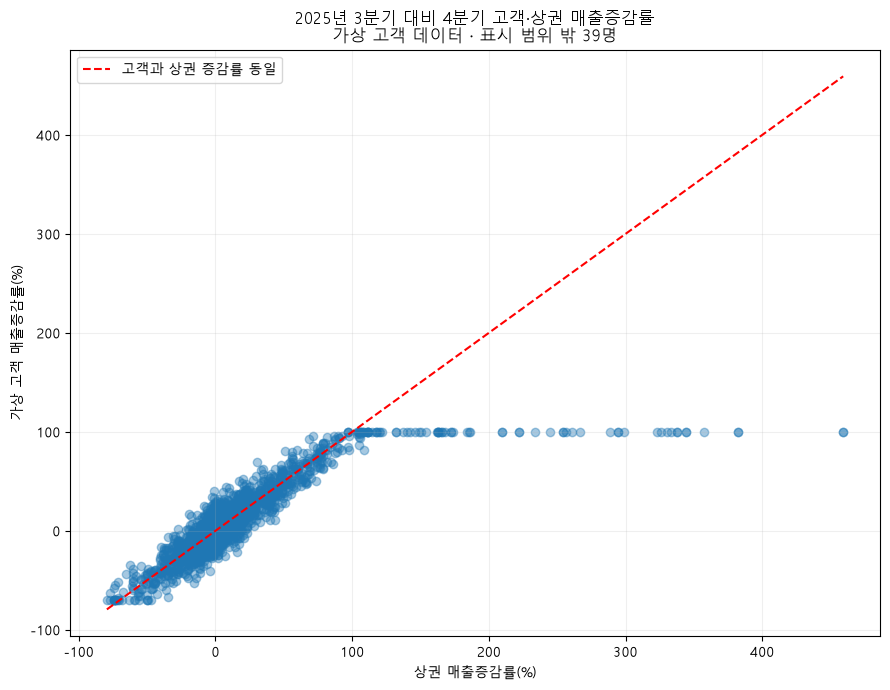

In [12]:
x_low, x_high = valid_plot[
    "market_sales_change_pct"
].quantile([0.01, 0.99])

y_low, y_high = valid_plot[
    "customer_sales_change_pct"
].quantile([0.01, 0.99])

scatter_data = valid_plot[
    valid_plot["market_sales_change_pct"].between(x_low, x_high)
    & valid_plot["customer_sales_change_pct"].between(y_low, y_high)
].copy()

excluded_count = len(valid_plot) - len(scatter_data)

plt.figure(figsize=(9, 7))

plt.scatter(
    scatter_data["market_sales_change_pct"],
    scatter_data["customer_sales_change_pct"],
    alpha=0.4
)

line_min = min(x_low, y_low)
line_max = max(x_high, y_high)

plt.plot(
    [line_min, line_max],
    [line_min, line_max],
    color="red",
    linestyle="--",
    label="고객과 상권 증감률 동일"
)

plt.xlabel("상권 매출증감률(%)")
plt.ylabel("가상 고객 매출증감률(%)")

plt.title(
    "2025년 3분기 대비 4분기 고객·상권 매출증감률\n"
    f"가상 고객 데이터 · 표시 범위 밖 {excluded_count}명"
)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    figure_dir / "customer_market_scatter.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

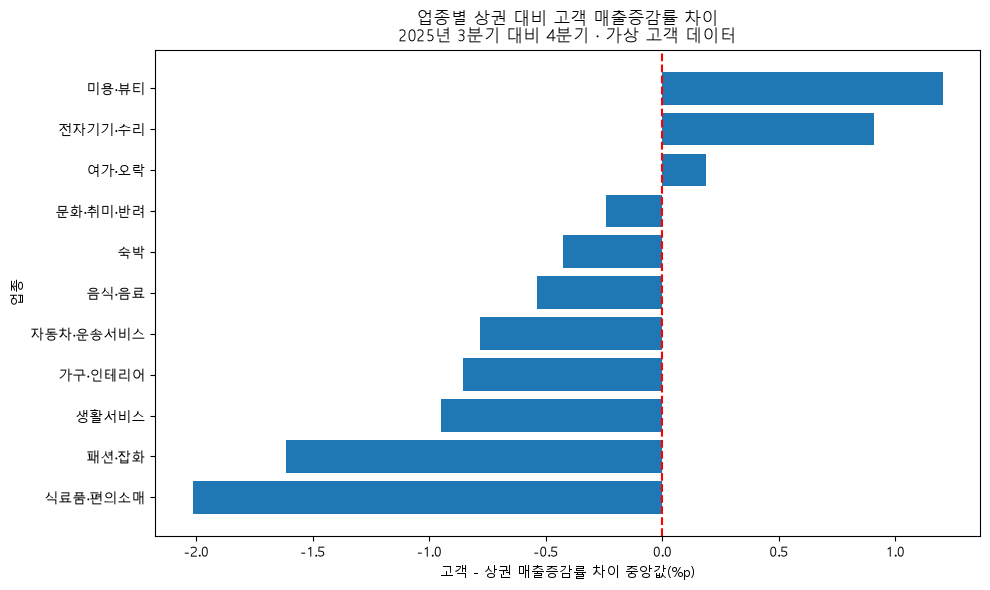

In [13]:
industry_plot = industry_summary.sort_values(
    "relative_change_median_pp"
)

plt.figure(figsize=(10, 6))

plt.barh(
    industry_plot["industry"],
    industry_plot["relative_change_median_pp"]
)

plt.axvline(0, color="red", linestyle="--")

plt.xlabel("고객 - 상권 매출증감률 차이 중앙값(%p)")
plt.ylabel("업종")

plt.title(
    "업종별 상권 대비 고객 매출증감률 차이\n"
    "2025년 3분기 대비 4분기 · 가상 고객 데이터"
)

plt.tight_layout()

plt.savefig(
    figure_dir / "industry_relative_change.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

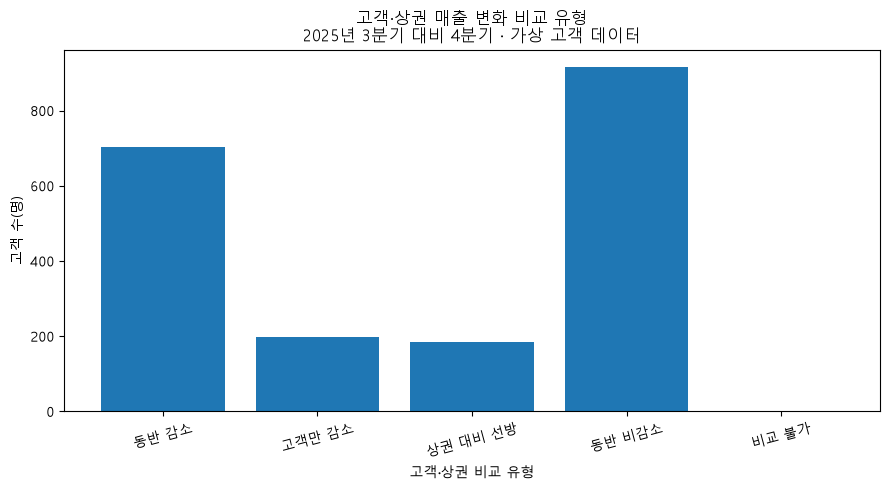

In [14]:
type_order = [
    "동반 감소",
    "고객만 감소",
    "상권 대비 선방",
    "동반 비감소",
    "비교 불가"
]

type_count = (
    comparison["comparison_type"]
    .value_counts()
    .reindex(type_order, fill_value=0)
)

plt.figure(figsize=(9, 5))

plt.bar(
    type_count.index,
    type_count.values
)

plt.xlabel("고객·상권 비교 유형")
plt.ylabel("고객 수(명)")

plt.title(
    "고객·상권 매출 변화 비교 유형\n"
    "2025년 3분기 대비 4분기 · 가상 고객 데이터"
)

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    figure_dir / "comparison_type_count.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [15]:
output_dir = data_dir / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

customer_result = comparison[
    [
        "customer_id",
        "base_quarter",
        "comparison_quarter",
        "region_code",
        "region_name",
        "industry",
        "customer_sales_change_pct",
        "market_sales_change_pct",
        "relative_change_pp",
        "comparison_type",
        "comparison_valid"
    ]
].copy()

customer_result.to_csv(
    output_dir / "customer_market_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

industry_summary.to_csv(
    output_dir / "industry_market_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

region_summary.to_csv(
    output_dir / "region_market_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료")
print(output_dir / "customer_market_comparison.csv")
print(output_dir / "industry_market_summary.csv")
print(output_dir / "region_market_summary.csv")
print("그래프 저장 위치:", figure_dir)

저장 완료
c:\Users\user\Documents\GitHub\kb_project\data\processed\customer_market_comparison.csv
c:\Users\user\Documents\GitHub\kb_project\data\processed\industry_market_summary.csv
c:\Users\user\Documents\GitHub\kb_project\data\processed\region_market_summary.csv
그래프 저장 위치: c:\Users\user\Documents\GitHub\kb_project\report\figures


In [16]:
validation_results = {
    "고객 단위 추출 후 2000명": len(customer) == 2000,
    
    "고유 고객 수 일치":
        len(customer) == customer["customer_id"].nunique(),
    
    "JOIN 후 행 수 유지":
        len(comparison) == len(customer_compare),
    
    "모든 고객 JOIN 성공":
        comparison["_merge"].eq("both").all(),
    
    "상권 증감률 재계산 결과 일치":
        np.isclose(
            comparison["stored_market_change_pct"],
            comparison["market_sales_change_pct"],
            equal_nan=True
        ).all(),
    
    "비교 유형 합계 일치":
        comparison["comparison_type"].value_counts().sum()
        == len(comparison),
    
    "결측값 비교 불가 처리":
        comparison.loc[
            ~comparison["comparison_valid"],
            "comparison_type"
        ].eq("비교 불가").all()
}

validation_table = pd.Series(
    validation_results,
    name="검증 결과"
).to_frame()

display(validation_table)

,검증 결과
고객 단위 추출 후 2000명,True
고유 고객 수 일치,True
JOIN 후 행 수 유지,True
모든 고객 JOIN 성공,True
상권 증감률 재계산 결과 일치,False
비교 유형 합계 일치,True
결측값 비교 불가 처리,True


In [17]:
rate_check = comparison[
    [
        "customer_id",
        "stored_market_change_pct",
        "market_sales_change_pct"
    ]
].dropna().copy()

rate_check["difference_pp"] = (
    rate_check["stored_market_change_pct"]
    - rate_check["market_sales_change_pct"]
)

rate_check["absolute_difference_pp"] = (
    rate_check["difference_pp"].abs()
)

print(
    "최대 차이(%p):",
    rate_check["absolute_difference_pp"].max()
)

print(
    "평균 차이(%p):",
    rate_check["absolute_difference_pp"].mean()
)

display(
    rate_check.sort_values(
        "absolute_difference_pp",
        ascending=False
    ).head(10)
)

최대 차이(%p): 0.004996008516016559
평균 차이(%p): 0.002527616173738833


,customer_id,stored_market_change_pct,market_sales_change_pct,difference_pp,absolute_difference_pp
1222,C04_1555,-40.30,-40.304996,0.004996,0.004996
1564,C04_1183,17.01,17.014995,-0.004995,0.004995
1824,C04_1055,-21.50,-21.504993,0.004993,0.004993
1987,C04_1319,17.10,17.095017,0.004983,0.004983
1719,C04_0947,9.13,9.125020,0.004980,0.004980
1618,C04_0643,2.38,2.375025,0.004975,0.004975
782,C04_1127,2.38,2.375025,0.004975,0.004975
1457,C04_0891,-22.81,-22.805025,-0.004975,0.004975
1420,C04_0787,11.16,11.155026,0.004974,0.004974
1595,C04_0790,-10.36,-10.355026,-0.004974,0.004974


In [18]:
market_change_matches = np.isclose(
    comparison["stored_market_change_pct"],
    comparison["market_sales_change_pct"],
    atol=0.005001,
    rtol=0,
    equal_nan=True
).all()

print("반올림 자릿수를 고려한 일치 여부:", market_change_matches)

반올림 자릿수를 고려한 일치 여부: True


In [19]:
validation_results["상권 증감률 재계산 결과 일치"] = (
    market_change_matches
)

validation_table = pd.Series(
    validation_results,
    name="검증 결과"
).to_frame()

display(validation_table)

,검증 결과
고객 단위 추출 후 2000명,True
고유 고객 수 일치,True
JOIN 후 행 수 유지,True
모든 고객 JOIN 성공,True
상권 증감률 재계산 결과 일치,True
비교 유형 합계 일치,True
결측값 비교 불가 처리,True


In [20]:
print("분석 대상 고객 수:", comparison["customer_id"].nunique())
print("비교 가능 고객 수:", comparison["comparison_valid"].sum())

print("\n[고객·상권 비교 유형]")

type_result = (
    comparison["comparison_type"]
    .value_counts()
    .rename_axis("comparison_type")
    .reset_index(name="customer_count")
)

type_result["rate_pct"] = (
    type_result["customer_count"]
    / len(comparison) * 100
).round(2)

display(type_result)

print("\n[업종별 비교 결과]")

display(
    industry_summary[
        [
            "industry",
            "total_customers",
            "customer_decrease_rate_pct",
            "relative_change_mean_pp",
            "relative_change_median_pp"
        ]
    ]
    .sort_values("relative_change_median_pp")
    .round(2)
)

print("\n[상권 대비 상대적으로 부진한 지역 상위 10개]")

display(
    region_summary[
        region_summary["total_customers"] >= 5
    ][
        [
            "region_code",
            "region_name",
            "total_customers",
            "customer_decrease_rate_pct",
            "relative_change_mean_pp",
            "relative_change_median_pp"
        ]
    ]
    .sort_values("relative_change_median_pp")
    .head(10)
    .round(2)
)

분석 대상 고객 수: 2000
비교 가능 고객 수: 2000

[고객·상권 비교 유형]


,comparison_type,customer_count,rate_pct
0,동반 비감소,916,45.80
1,동반 감소,702,35.10
2,고객만 감소,197,9.85
3,상권 대비 선방,185,9.25



[업종별 비교 결과]


,industry,total_customers,customer_decrease_rate_pct,relative_change_mean_pp,relative_change_median_pp
5,식료품·편의소매,210,53.33,-1.19,-2.02
10,패션·잡화,211,32.70,-33.85,-1.61
3,생활서비스,172,8.72,-6.46,-0.95
0,가구·인테리어,181,46.96,-21.24,-0.86
8,자동차·운송서비스,160,56.88,-0.08,-0.78
7,음식·음료,252,48.41,0.28,-0.54
4,숙박,82,53.66,-5.08,-0.42
1,문화·취미·반려,202,40.59,-23.12,-0.24
6,여가·오락,184,42.39,0.33,0.19
9,전자기기·수리,118,57.63,-80.39,0.91



[상권 대비 상대적으로 부진한 지역 상위 10개]


,region_code,region_name,total_customers,customer_decrease_rate_pct,relative_change_mean_pp,relative_change_median_pp
241,11500550,화곡2동,5,80.00,-13.73,-17.93
329,11620725,조원동,6,33.33,-402.91,-15.69
312,11590680,신대방2동,6,33.33,-25.83,-15.44
129,11305545,송중동,5,60.00,-4.63,-14.69
120,11290705,종암동,8,12.50,-39.55,-14.19
255,11530510,신도림동,7,42.86,-32.45,-13.66
173,11380520,불광1동,5,40.00,-5.85,-12.33
123,11290760,장위1동,5,60.00,-107.35,-12.30
34,11170570,원효로2동,5,20.00,-12.05,-11.77
101,11260620,묵1동,8,50.00,-12.12,-11.10
